In [1]:
!pip install -q segmentation-models-pytorch albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 82.8 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompati

In [2]:
import os, cv2, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.benchmark = True
print(f'GPU : {torch.cuda.get_device_name(0)}')
print('Ready!')

GPU : Tesla T4
Ready!


In [13]:
import os

base = '/kaggle/input/competitions/tgs-salt-identification-challenge'
for root, dirs, files in os.walk(base):
    depth = root.replace(base, '').count(os.sep)
    if depth < 4:
        print(f'{root}  ({len(files)} files)')

/kaggle/input/competitions/tgs-salt-identification-challenge  (7 files)


In [14]:
import os

base = '/kaggle/input/competitions/tgs-salt-identification-challenge'
for f in os.listdir(base):
    print(f)

depths.csv
sample_submission.csv
train.zip
competition_data.zip
test.zip
train.csv
flamingo.zip


In [15]:
import zipfile
import os

base = '/kaggle/input/competitions/tgs-salt-identification-challenge'
out  = '/kaggle/working/tgs_data'
os.makedirs(out, exist_ok=True)

# Unzip train.zip
print('Unzipping train.zip...')
with zipfile.ZipFile(f'{base}/train.zip', 'r') as z:
    z.extractall(out)
print('Done!')

# Check what we got
for root, dirs, files in os.walk(out):
    depth = root.replace(out, '').count(os.sep)
    if depth < 3:
        print(f'{root}  ({len(files)} files)')

Unzipping train.zip...
Done!
/kaggle/working/tgs_data  (0 files)
/kaggle/working/tgs_data/images  (4000 files)
/kaggle/working/tgs_data/masks  (4000 files)


In [19]:
import os

out = '/kaggle/working/tgs_data'
for root, dirs, files in os.walk(out):
    depth = root.replace(out, '').count(os.sep)
    if depth < 4:
        print(f'{root}  ({len(files)} files)')

/kaggle/working/tgs_data  (0 files)
/kaggle/working/tgs_data/images  (4000 files)
/kaggle/working/tgs_data/masks  (4000 files)


In [20]:
IMG_H   = 128
IMG_W   = 128
CLASSES = 1
BS      = 32
EPOCHS  = 60
LR      = 1e-3
THR     = 0.5
SEED    = 42

DATA  = '/kaggle/working/tgs_data'
IMGS  = f'{DATA}/images'
MASKS = f'{DATA}/masks'
CSV   = '/kaggle/input/competitions/tgs-salt-identification-challenge/train.csv'
OUT   = '/kaggle/working/outputs'
os.makedirs(OUT, exist_ok=True)

print(f'Train images : {len(os.listdir(IMGS)):,}')
print(f'Train masks  : {len(os.listdir(MASKS)):,}')
print(f'Epochs       : {EPOCHS}  Batch : {BS}')

Train images : 4,000
Train masks  : 4,000
Epochs       : 60  Batch : 32


In [21]:
df = pd.read_csv(CSV)

# Check how many images have salt vs empty
df['has_salt'] = df['id'].apply(lambda x:
    cv2.imread(os.path.join(MASKS, f'{x}.png'), cv2.IMREAD_GRAYSCALE).max() > 0
)

total = len(df)
salt  = df['has_salt'].sum()
empty = total - salt

print(f'Total images  : {total:,}')
print(f'Has salt      : {salt:,}  ({100*salt/total:.1f}%)')
print(f'Empty (no salt): {empty:,}  ({100*empty/total:.1f}%)')
print(df.head())

Total images  : 4,000
Has salt      : 2,438  (61.0%)
Empty (no salt): 1,562  (39.0%)
           id                                           rle_mask  has_salt
0  575d24d81d                                                NaN     False
1  a266a2a9df                                          5051 5151      True
2  75efad62c1  9 93 109 94 210 94 310 95 411 95 511 96 612 96...      True
3  34e51dba6a  48 54 149 54 251 53 353 52 455 51 557 50 659 4...      True
4  4875705fb0  1111 1 1212 1 1313 1 1414 1 1514 2 1615 2 1716...      True


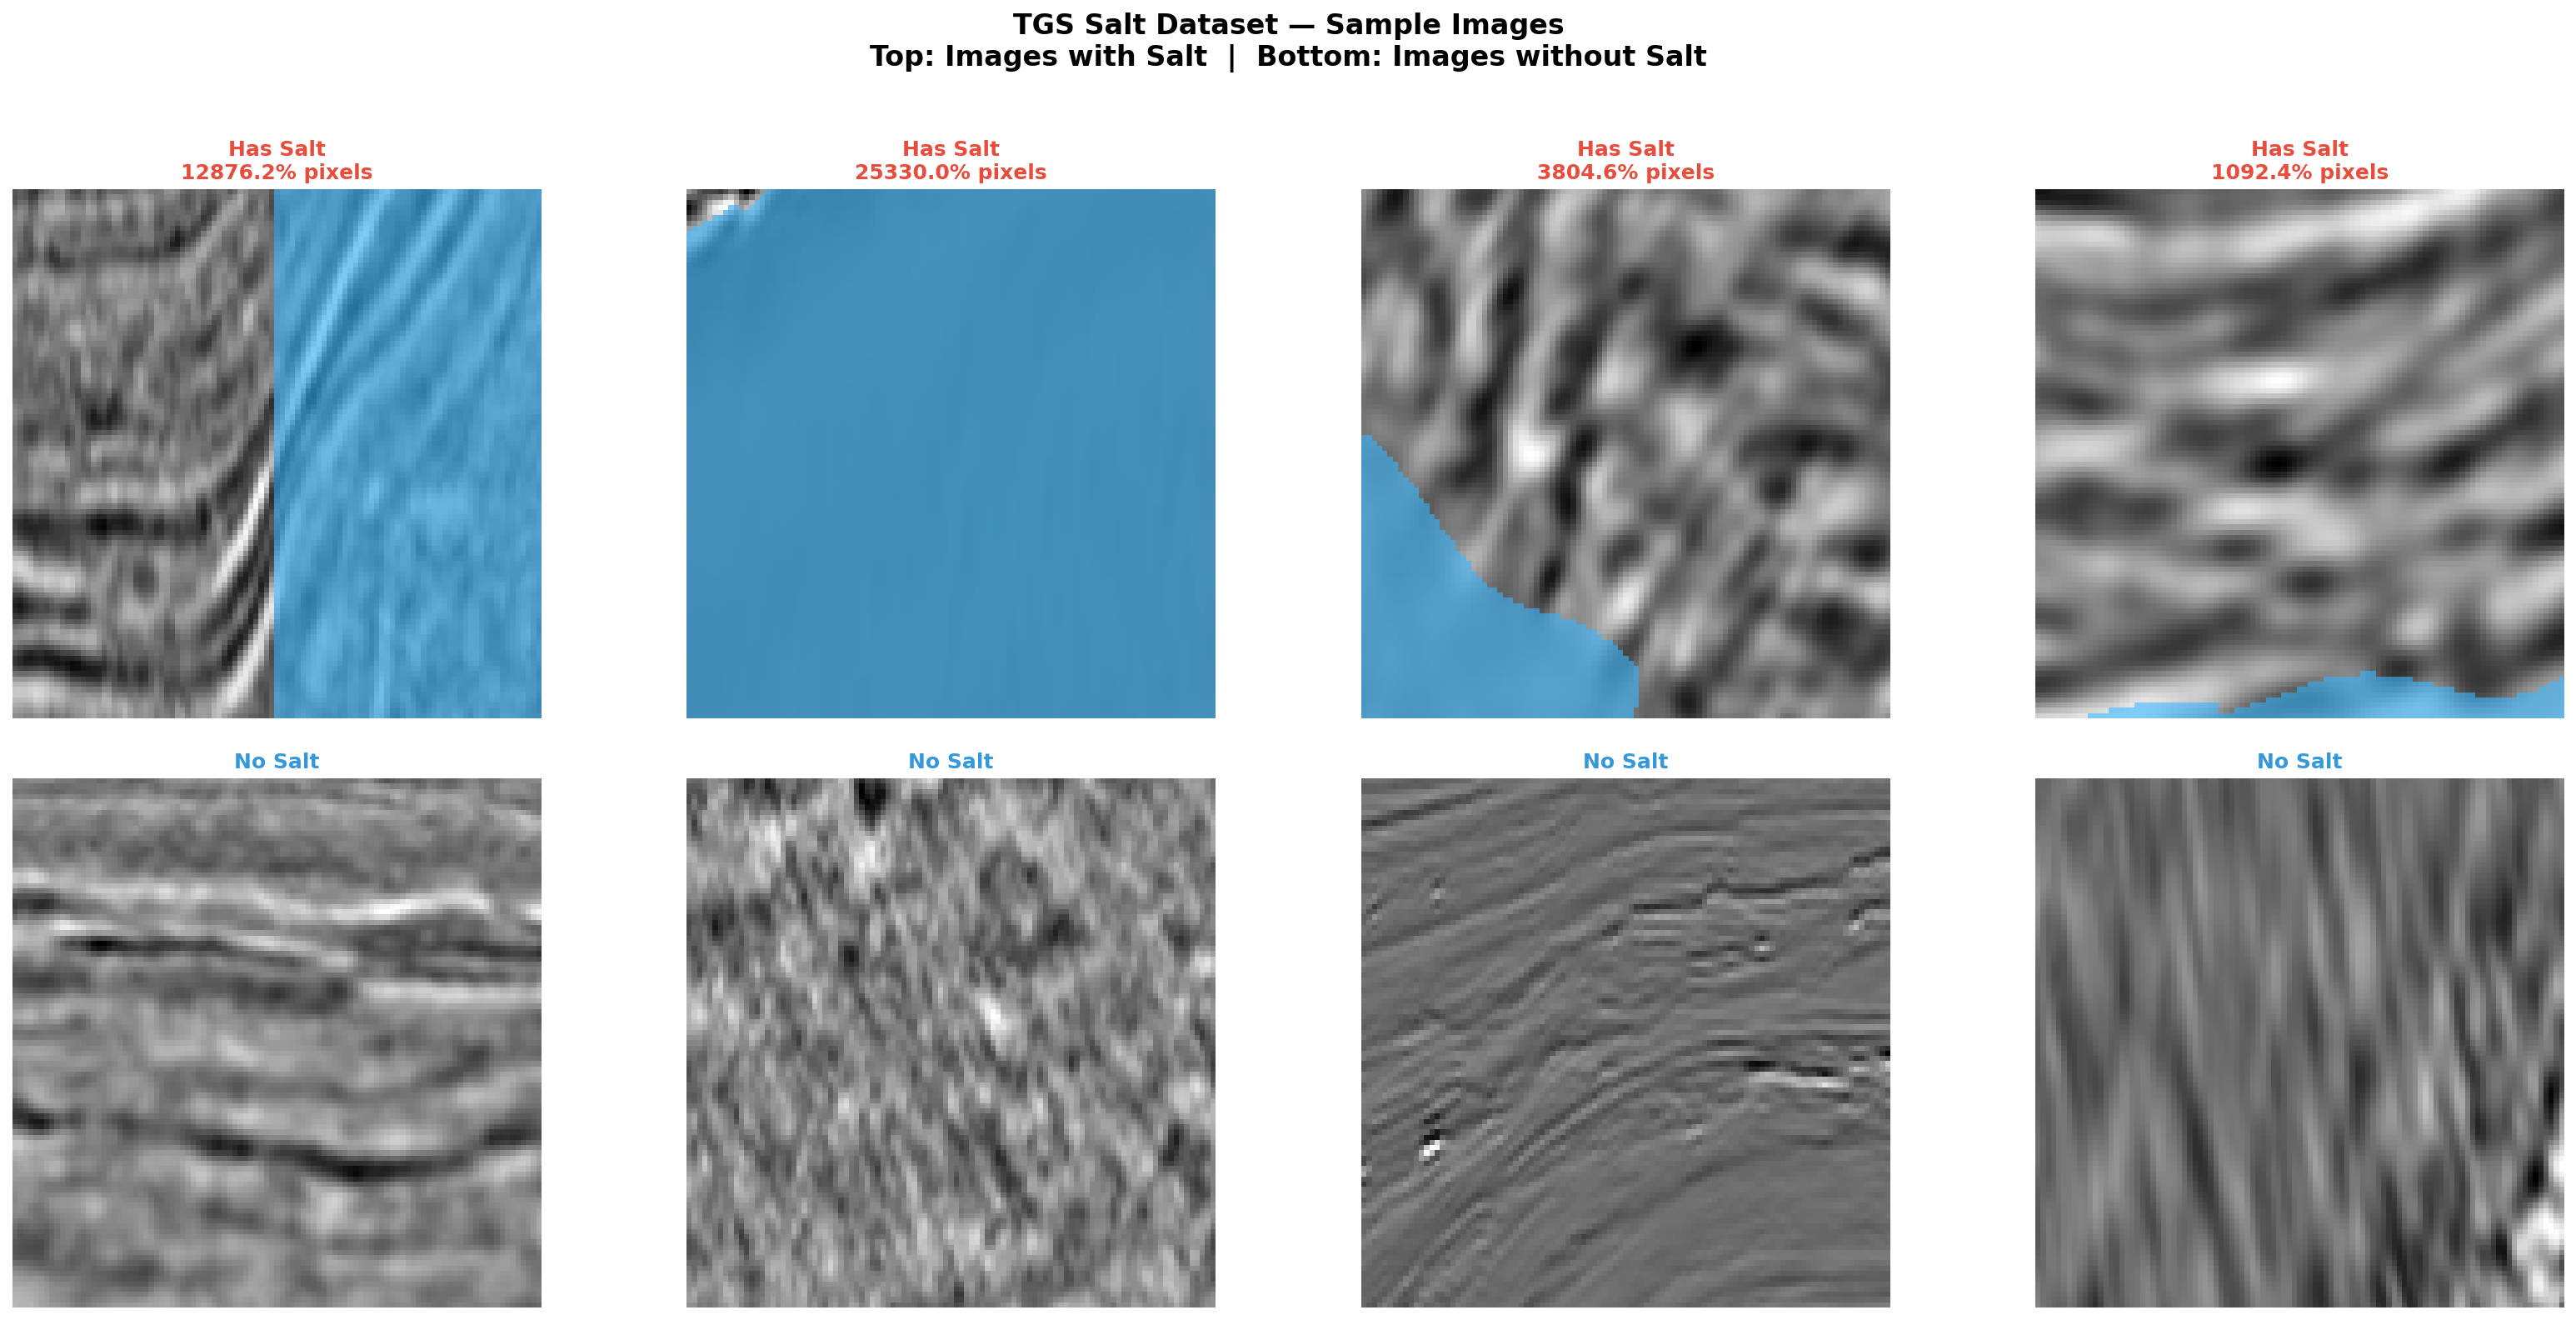

Saved samples.png


In [44]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11), dpi=150)
fig.patch.set_facecolor('white')
fig.suptitle(
    'TGS Salt Dataset — Sample Images\n'
    'Top: Images with Salt  |  Bottom: Images without Salt',
    fontsize=16, fontweight='bold'
)

salt_samples  = df[df['has_salt']==True].head(4)
empty_samples = df[df['has_salt']==False].head(4)

for i, (_, row) in enumerate(salt_samples.iterrows()):
    img  = cv2.imread(os.path.join(IMGS,  f'{row["id"]}.png'))
    mask = cv2.imread(os.path.join(MASKS, f'{row["id"]}.png'),
                      cv2.IMREAD_GRAYSCALE)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    overlay = img_rgb.copy()
    overlay[mask > 0] = (
        overlay[mask > 0] * 0.4 +
        np.array([56, 182, 255]) * 0.6
    ).astype(np.uint8)
    pct = round(100 * mask.mean(), 1)
    axes[0][i].imshow(overlay)
    axes[0][i].set_title(f'Has Salt\n{pct}% pixels',
                          fontsize=12, fontweight='bold', color='#e74c3c')
    axes[0][i].axis('off')

for i, (_, row) in enumerate(empty_samples.iterrows()):
    img = cv2.imread(os.path.join(IMGS, f'{row["id"]}.png'))
    axes[1][i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), cmap='gray')
    axes[1][i].set_title('No Salt',
                          fontsize=12, fontweight='bold', color='#3498db')
    axes[1][i].axis('off')

plt.tight_layout(pad=3.0)
plt.savefig(f'{OUT}/samples.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved samples.png')

In [23]:
train_tf = A.Compose([
    A.Resize(IMG_H, IMG_W),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.4),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                       rotate_limit=15, p=0.5),
    A.OneOf([A.GaussNoise(p=1), A.GaussianBlur(p=1)], p=0.3),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(IMG_H, IMG_W),
    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

print('Augmentations:')
for t in train_tf.transforms:
    print(f'  • {type(t).__name__}')

Augmentations:
  • Resize
  • HorizontalFlip
  • VerticalFlip
  • RandomBrightnessContrast
  • ShiftScaleRotate
  • OneOf
  • Normalize
  • ToTensorV2


In [24]:
class TGSDataset(Dataset):
    """
    TGS Salt dataset.
    Each image has one binary mask — salt pixels = 1, no salt = 0.
    Much simpler than steel dataset — no class imbalance problem.
    """
    def __init__(self, df, img_dir, mask_dir, transform=None):
        self.ids       = df['id'].values
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]

        # Load image (RGB)
        img  = cv2.imread(os.path.join(self.img_dir, f'{img_id}.png'))
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Load mask (binary: 0 or 1)
        mask = cv2.imread(os.path.join(self.mask_dir, f'{img_id}.png'),
                          cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)
        mask = mask[:, :, np.newaxis]   # add channel dim: H x W x 1

        if self.transform:
            out  = self.transform(image=img, mask=mask)
            img  = out['image']
            mask = out['mask'].permute(2, 0, 1)   # 1 x H x W
        return img, mask, img_id


# Split data
train_ids, val_ids = train_test_split(
    df['id'].values, test_size=0.15, random_state=SEED)

train_df = df[df['id'].isin(train_ids)].reset_index(drop=True)
val_df   = df[df['id'].isin(val_ids)].reset_index(drop=True)

train_ds = TGSDataset(train_df, IMGS, MASKS, train_tf)
val_ds   = TGSDataset(val_df,   IMGS, MASKS, val_tf)

train_loader = DataLoader(train_ds, batch_size=BS, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BS, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

print(f'Train : {len(train_ds):,} images')
print(f'Val   : {len(val_ds):,} images')

Train : 3,400 images
Val   : 600 images


In [25]:
model = smp.Unet(
    encoder_name    = 'resnet34',
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = CLASSES,    # 1 output channel
    activation      = None,
).to(device)

total = sum(p.numel() for p in model.parameters())
print(f'Model  : U-Net + ResNet34 (ImageNet pretrained)')
print(f'Params : {total:,}')
print(f'Output : 1 channel (salt probability per pixel)')

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model  : U-Net + ResNet34 (ImageNet pretrained)
Params : 24,436,369
Output : 1 channel (salt probability per pixel)


In [26]:
class LovaszLoss(nn.Module):
    """
    Lovász loss directly optimizes IoU.
    Your paper used this after epoch 50.
    Works by sorting prediction errors and computing gradient of IoU.
    """
    def forward(self, logits, targets):
        probs         = torch.sigmoid(logits).reshape(-1)
        targets_flat  = targets.reshape(-1)
        signs         = 2.0 * targets_flat - 1.0
        errors        = 1.0 - probs * signs
        errors_sorted, perm = torch.sort(errors, descending=True)
        gt_sorted     = targets_flat[perm]
        grad          = self._lovasz_grad(gt_sorted)
        return torch.dot(torch.relu(errors_sorted), grad)

    def _lovasz_grad(self, gt_sorted):
        p    = len(gt_sorted)
        gts  = gt_sorted.sum()
        iou  = 1.0 - (gts - gt_sorted.cumsum(0)) / \
               (gts + (1 - gt_sorted).cumsum(0)).clamp(min=1)
        grad = iou.clone()
        grad[1:p] = grad[1:p] - grad[0:p-1]
        return grad


class DiceLoss(nn.Module):
    """Dice loss = 1 - (2*overlap) / (pred + target)"""
    def forward(self, logits, targets, smooth=1.0):
        probs = torch.sigmoid(logits).reshape(-1)
        t     = targets.reshape(-1)
        inter = (probs * t).sum()
        return 1 - (2*inter + smooth) / (probs.sum() + t.sum() + smooth)


class TwoStageLoss(nn.Module):
    """
    Exactly your paper's training strategy:
    Epochs  1-50 : BCE loss  → stable early training
    Epochs 51-60 : Dice + Lovász → directly maximize IoU
    """
    def __init__(self):
        super().__init__()
        self.bce    = nn.BCEWithLogitsLoss()
        self.dice   = DiceLoss()
        self.lovasz = LovaszLoss()
        self.epoch  = 1

    def forward(self, logits, targets):
        if self.epoch <= 50:
            return self.bce(logits, targets)
        else:
            return 0.5 * self.dice(logits, targets) + \
                   0.5 * self.lovasz(logits, targets)


def iou_score(pred, target, thr=THR, eps=1e-6):
    """IoU = intersection / union"""
    pb    = (pred > thr).float()
    inter = (pb * target).sum()
    union = pb.sum() + target.sum() - inter
    return ((inter + eps) / (union + eps)).item()


loss_fn   = TwoStageLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = torch.cuda.amp.GradScaler()

print('Stage 1 (ep 1-50)  : BCE loss')
print('Stage 2 (ep 51-60) : Dice + Lovász loss')
print('Optimizer : AdamW + CosineAnnealingLR')

Stage 1 (ep 1-50)  : BCE loss
Stage 2 (ep 51-60) : Dice + Lovász loss
Optimizer : AdamW + CosineAnnealingLR


In [27]:
def train_epoch(model, loader):
    model.train()
    total = 0.0
    for imgs, masks, _ in tqdm(loader, desc='Train', leave=False):
        imgs, masks = imgs.to(device, non_blocking=True), \
                      masks.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            loss = loss_fn(model(imgs), masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def val_epoch(model, loader):
    model.eval()
    total, preds, masks = 0.0, [], []
    for imgs, m, _ in tqdm(loader, desc='Val  ', leave=False):
        imgs, m = imgs.to(device, non_blocking=True), \
                  m.to(device, non_blocking=True)
        with torch.cuda.amp.autocast():
            p = model(imgs)
            total += loss_fn(p, m).item()
        preds.append(p.cpu())
        masks.append(m.cpu())
    preds = torch.cat(preds)
    masks = torch.cat(masks)
    iou   = round(iou_score(torch.sigmoid(preds), masks), 4)
    return total/len(loader), iou, preds, masks


print('Functions ready')

Functions ready


In [28]:
best    = 0.0
ckpt    = f'{OUT}/best_model.pth'
history = {'tl':[], 'vl':[], 'iou':[]}

print(f'Training {EPOCHS} epochs on {device}')
print('Stage 1 (BCE)       : epochs 1-50')
print('Stage 2 (Dice+Lov)  : epochs 51-60')
print('='*50)

for ep in range(1, EPOCHS+1):
    loss_fn.epoch = ep   # update loss stage

    if ep == 51:
        print('\n>>> Stage 2 started: Dice + Lovász loss <<<\n')

    t0 = time.time()
    tl = train_epoch(model, train_loader)
    vl, iou, vp, vm = val_epoch(model, val_loader)
    scheduler.step()
    t  = time.time() - t0

    history['tl'].append(tl)
    history['vl'].append(vl)
    history['iou'].append(iou)

    print(f'Ep {ep:02d}/{EPOCHS}  '
          f'loss={tl:.4f}/{vl:.4f}  '
          f'IoU={iou:.4f}  '
          f'{t/60:.1f}min  '
          f'left={t*(EPOCHS-ep)/60:.0f}min')

    if iou > best:
        best = iou
        torch.save(model.state_dict(), ckpt)
        print(f'  ✅ Best: {best:.4f}')

print(f'\nDone! Best IoU: {best:.4f}')

Training 60 epochs on cuda
Stage 1 (BCE)       : epochs 1-50
Stage 2 (Dice+Lov)  : epochs 51-60


Ep 01/60  loss=0.4560/0.3836  IoU=0.4422  1.4min  left=82min
  ✅ Best: 0.4422


Ep 02/60  loss=0.3776/0.3927  IoU=0.3482  0.1min  left=8min


Ep 03/60  loss=0.3540/0.3207  IoU=0.5732  0.1min  left=8min
  ✅ Best: 0.5732


Ep 04/60  loss=0.3288/0.3100  IoU=0.5308  0.1min  left=8min


...

Ep 56/60  loss=0.4835/0.4517  IoU=0.8378  0.2min  left=1min


Ep 57/60  loss=0.4869/0.4499  IoU=0.8442  0.2min  left=0min
  ✅ Best: 0.8442


Ep 58/60  loss=0.4881/0.4483  IoU=0.8418  0.1min  left=0min


Ep 59/60  loss=0.4887/0.4501  IoU=0.8420  0.1min  left=0min


Ep 60/60  loss=0.4877/0.4507  IoU=0.8453  0.2min  left=0min
  ✅ Best: 0.8453

Done! Best IoU: 0.8453


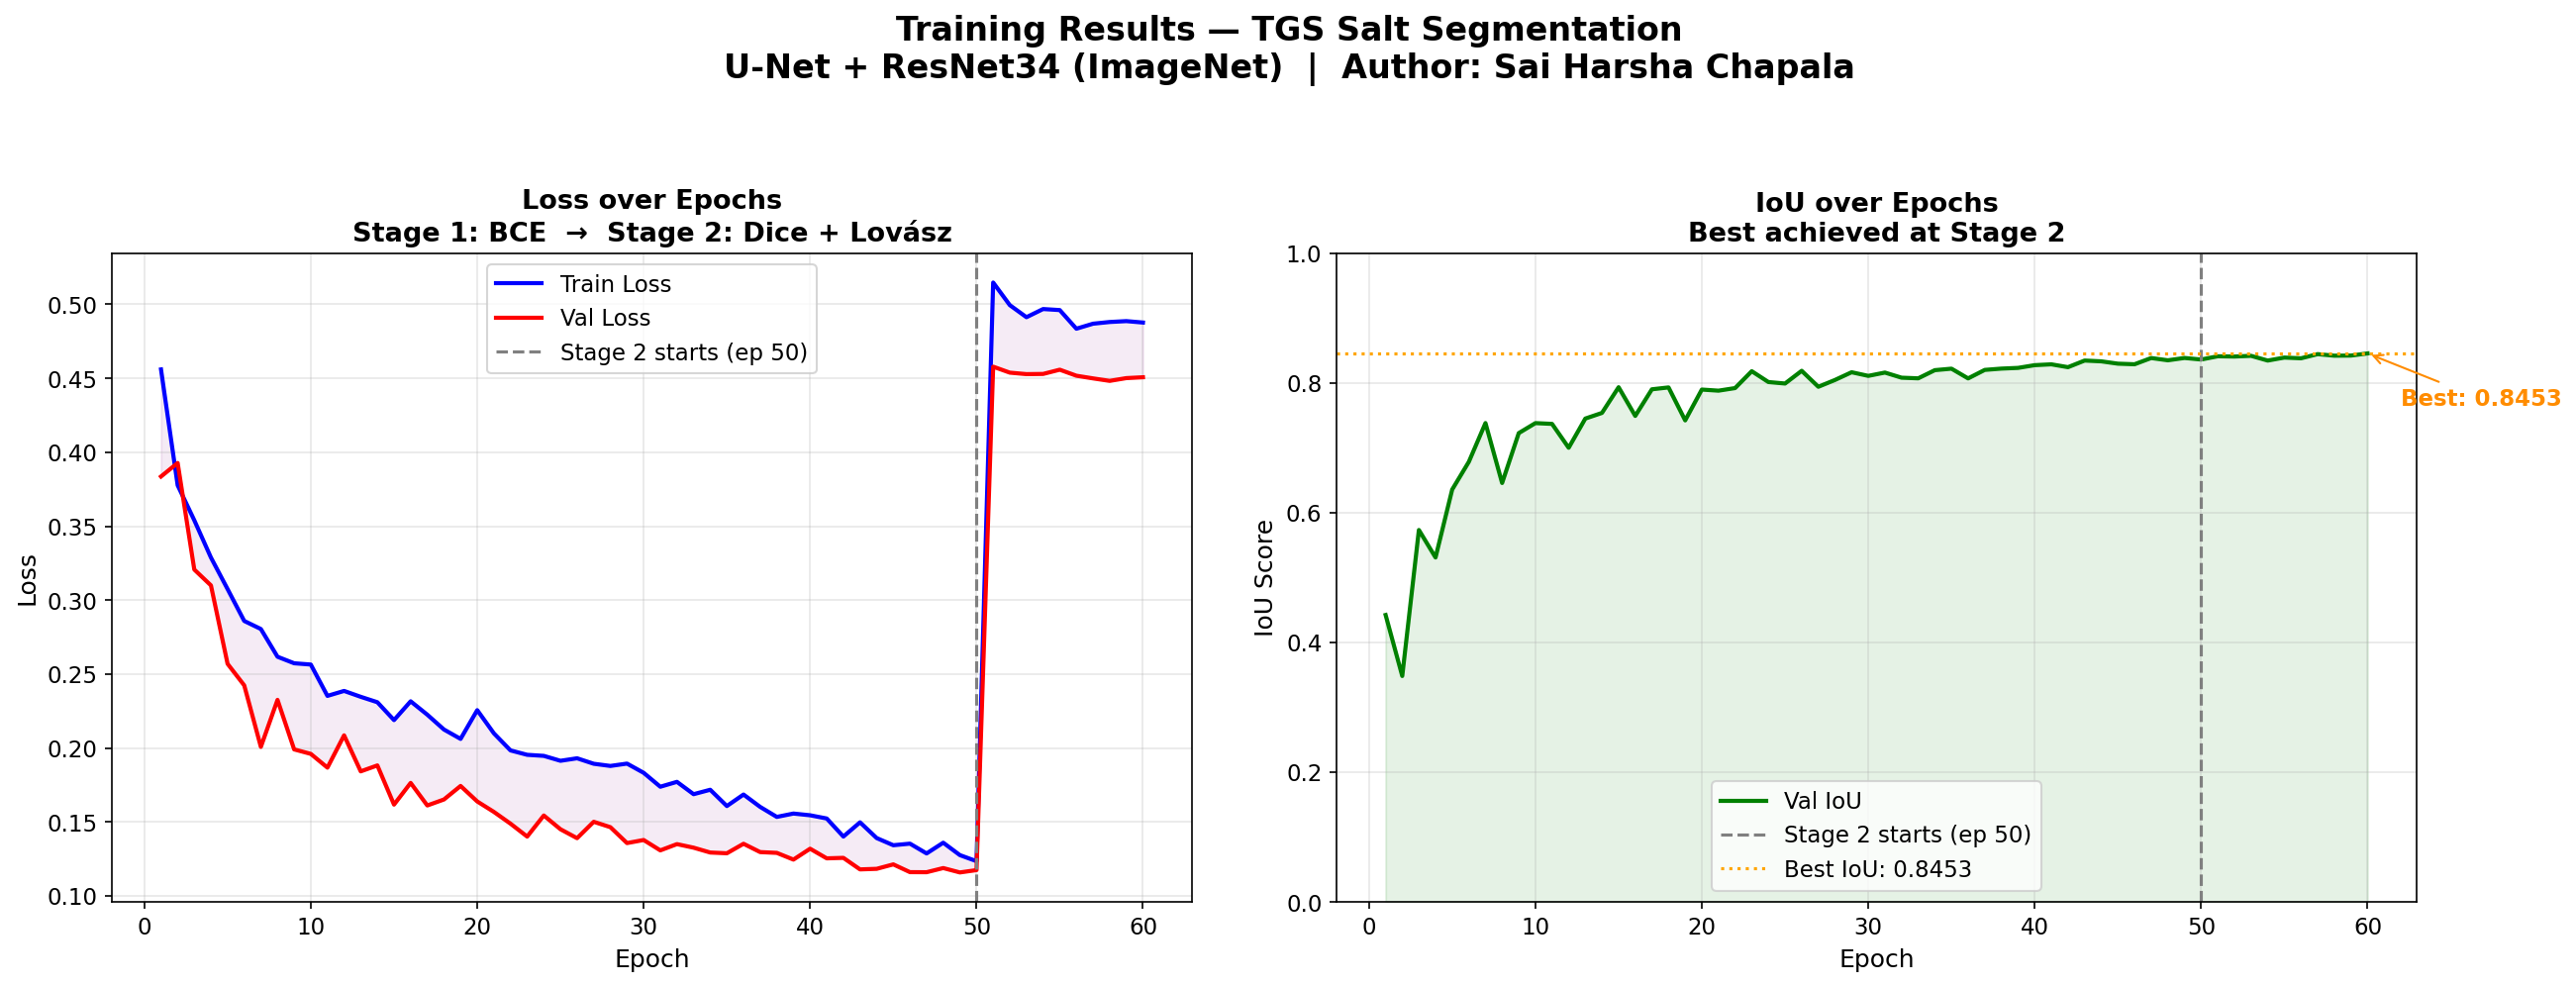

Saved curves.png


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=150)
fig.patch.set_facecolor('white')
fig.suptitle(
    'Training Results — TGS Salt Segmentation\n'
    'U-Net + ResNet34 (ImageNet)  |  Author: Sai Harsha Chapala',
    fontsize=16, fontweight='bold'
)

ep = range(1, len(history['tl'])+1)

# Loss curve
axes[0].plot(ep, history['tl'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(ep, history['vl'], 'r-', label='Val Loss',   linewidth=2)
axes[0].axvline(x=50, color='gray', linestyle='--',
                linewidth=1.5, label='Stage 2 starts (ep 50)')
axes[0].fill_between(ep, history['tl'], history['vl'],
                     alpha=0.08, color='purple')
axes[0].set_title('Loss over Epochs\nStage 1: BCE  →  Stage 2: Dice + Lovász',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss',  fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].tick_params(labelsize=11)

# IoU curve
axes[1].plot(ep, history['iou'], 'g-', linewidth=2, label='Val IoU')
axes[1].axvline(x=50, color='gray', linestyle='--',
                linewidth=1.5, label='Stage 2 starts (ep 50)')
axes[1].axhline(y=best, color='orange', linestyle=':',
                linewidth=1.5, label=f'Best IoU: {best:.4f}')
axes[1].fill_between(ep, 0, history['iou'], alpha=0.1, color='green')
axes[1].set_title('IoU over Epochs\nBest achieved at Stage 2',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('IoU Score', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].tick_params(labelsize=11)

# Annotate best IoU
best_ep = history['iou'].index(max(history['iou'])) + 1
axes[1].annotate(
    f'Best: {best:.4f}',
    xy=(best_ep, best),
    xytext=(best_ep + 2, best - 0.08),
    fontsize=11, color='darkorange', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='darkorange')
)

plt.tight_layout(pad=3.0)
plt.savefig(f'{OUT}/curves.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved curves.png')

In [43]:
# Train ResNet18 for comparison
model_r18 = smp.Unet(
    encoder_name    = 'resnet18',
    encoder_weights = 'imagenet',
    in_channels     = 3,
    classes         = CLASSES,
    activation      = None,
).to(device)

loss_fn_r18   = TwoStageLoss()
optimizer_r18 = optim.AdamW(model_r18.parameters(), lr=LR, weight_decay=1e-4)
scheduler_r18 = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer_r18, T_max=EPOCHS, eta_min=1e-6)
scaler_r18    = torch.cuda.amp.GradScaler()
best_r18      = 0.0
ckpt_r18      = f'{OUT}/best_model_r18.pth'
history_r18   = {'tl':[], 'vl':[], 'iou':[]}


def train_epoch_r18(model, loader):
    model.train()
    total = 0.0
    for imgs, masks, _ in tqdm(loader, desc='Train', leave=False):
        imgs, masks = imgs.to(device, non_blocking=True), \
                      masks.to(device, non_blocking=True)
        optimizer_r18.zero_grad()
        with torch.cuda.amp.autocast():
            loss = loss_fn_r18(model(imgs), masks)
        scaler_r18.scale(loss).backward()
        scaler_r18.unscale_(optimizer_r18)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler_r18.step(optimizer_r18)
        scaler_r18.update()
        total += loss.item()
    return total / len(loader)


@torch.no_grad()
def val_epoch_r18(model, loader):
    model.eval()
    total, preds, masks = 0.0, [], []
    for imgs, m, _ in tqdm(loader, desc='Val  ', leave=False):
        imgs, m = imgs.to(device, non_blocking=True), \
                  m.to(device, non_blocking=True)
        with torch.cuda.amp.autocast():
            p = model(imgs)
            total += loss_fn_r18(p, m).item()
        preds.append(p.cpu())
        masks.append(m.cpu())
    preds = torch.cat(preds)
    masks = torch.cat(masks)
    iou   = round(iou_score(torch.sigmoid(preds), masks), 4)
    return total/len(loader), iou, preds, masks


print('Training ResNet18 for comparison...')
print('='*50)

for ep in range(1, EPOCHS+1):
    loss_fn_r18.epoch = ep
    if ep == 51:
        print('\n>>> Stage 2: Dice + Lovász <<<\n')

    t0  = time.time()
    tl  = train_epoch_r18(model_r18, train_loader)
    vl, iou, vp, vm = val_epoch_r18(model_r18, val_loader)
    scheduler_r18.step()
    t   = time.time() - t0

    history_r18['tl'].append(tl)
    history_r18['vl'].append(vl)
    history_r18['iou'].append(iou)

    print(f'Ep {ep:02d}/{EPOCHS}  '
          f'loss={tl:.4f}/{vl:.4f}  '
          f'IoU={iou:.4f}  '
          f'{t/60:.1f}min  '
          f'left={t*(EPOCHS-ep)/60:.0f}min')

    if iou > best_r18:
        best_r18 = iou
        torch.save(model_r18.state_dict(), ckpt_r18)
        print(f'  ✅ Best ResNet18: {best_r18:.4f}')

print(f'\nDone ResNet18! Best IoU: {best_r18:.4f}')

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Training ResNet18 for comparison...


Ep 01/60  loss=0.4578/0.5106  IoU=0.2248  0.1min  left=7min
  ✅ Best ResNet18: 0.2248


Ep 02/60  loss=0.3902/0.3011  IoU=0.6264  0.1min  left=7min
  ✅ Best ResNet18: 0.6264


...

Ep 56/60  loss=0.5005/0.4464  IoU=0.8425  0.1min  left=0min


Ep 57/60  loss=0.4842/0.4452  IoU=0.8483  0.1min  left=0min


Ep 58/60  loss=0.4861/0.4458  IoU=0.8482  0.1min  left=0min


Ep 59/60  loss=0.4853/0.4465  IoU=0.8420  0.1min  left=0min


Ep 60/60  loss=0.4920/0.4462  IoU=0.8477  0.1min  left=0min

Done ResNet18! Best IoU: 0.8571


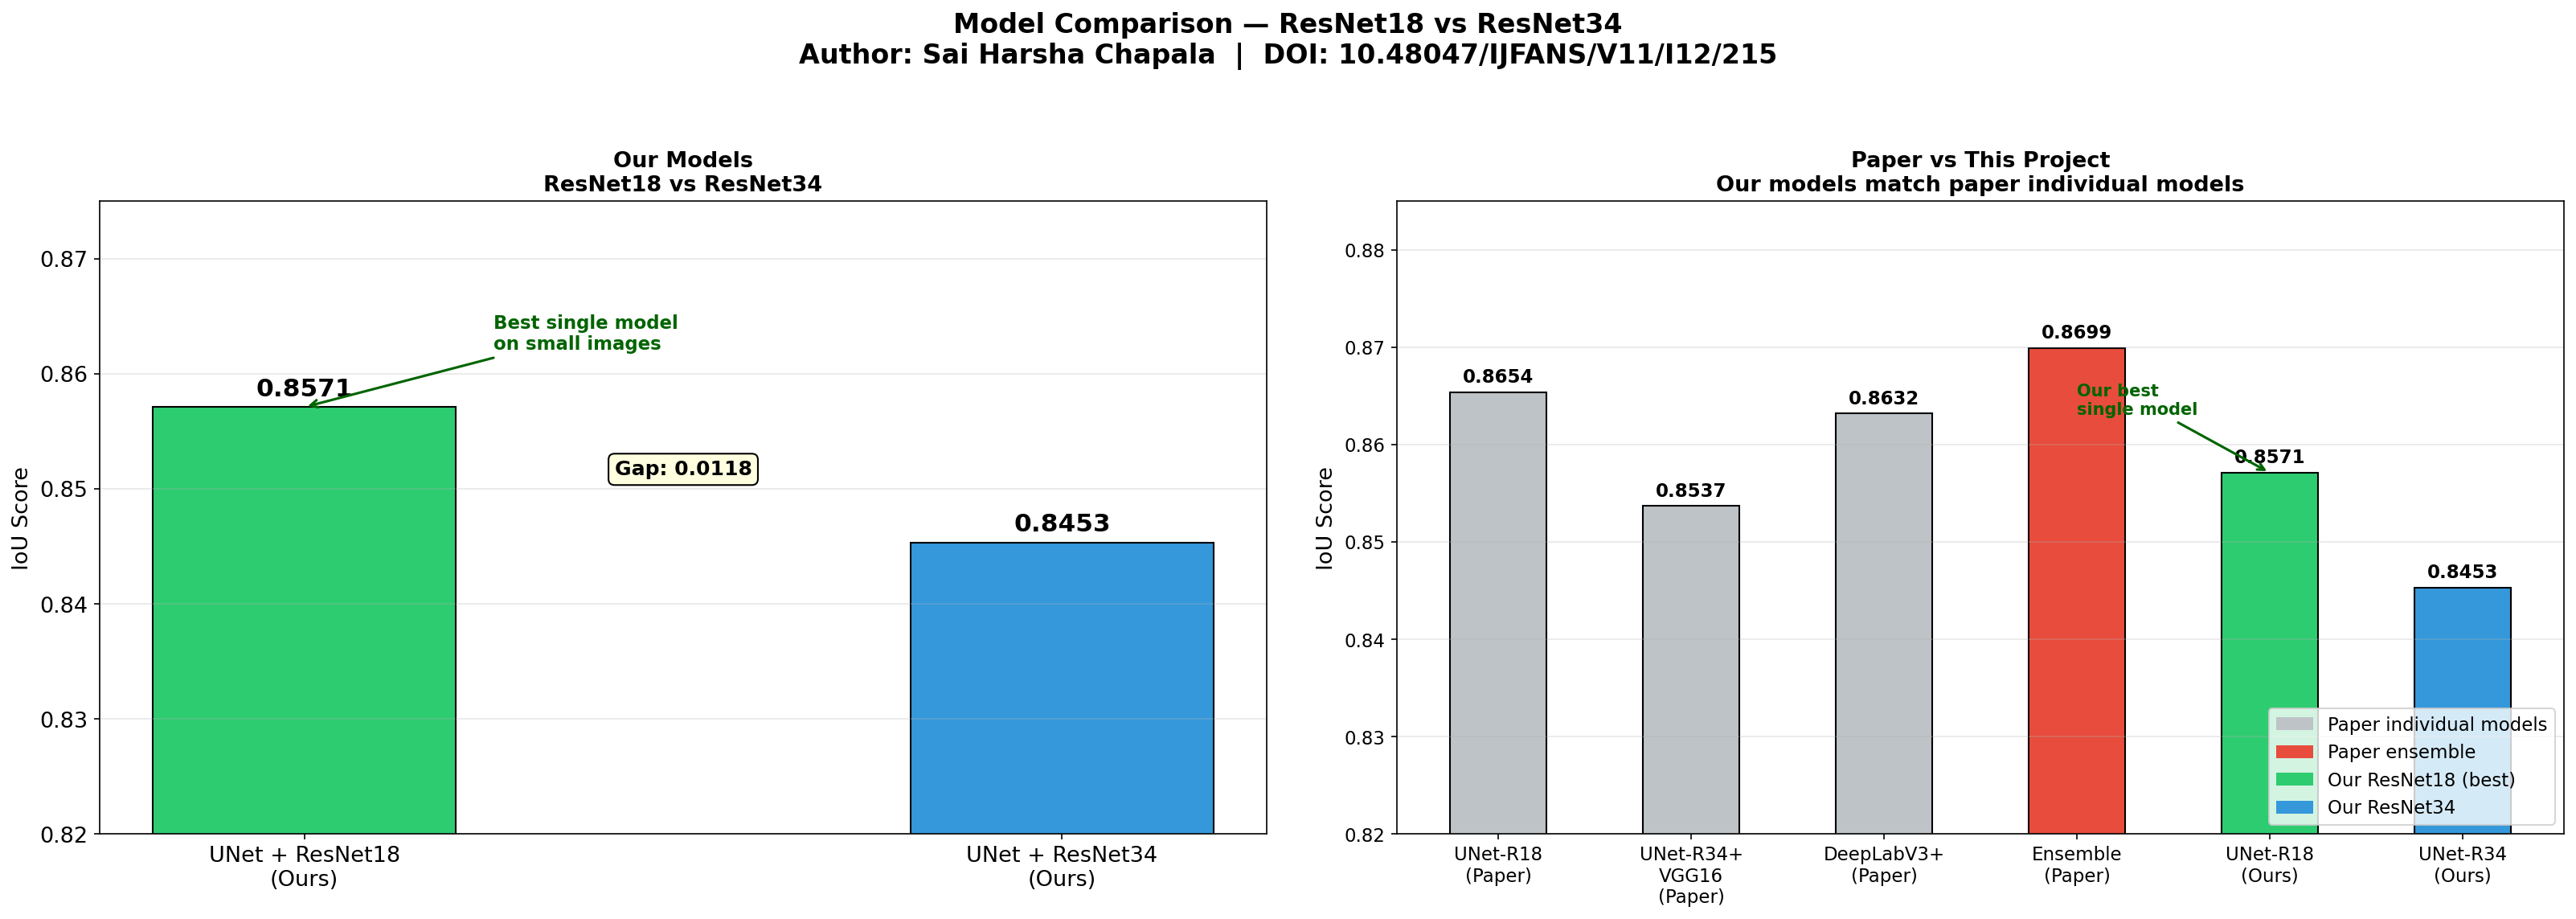

Saved comparison.png


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8), dpi=150)
fig.patch.set_facecolor('white')
fig.suptitle(
    'Model Comparison — ResNet18 vs ResNet34\n'
    'Author: Sai Harsha Chapala',
    fontsize=16, fontweight='bold'
)

# Chart 1: Our models only
models_p = ['UNet + ResNet18\n(Ours)', 'UNet + ResNet34\n(Ours)']
scores_p = [best_r18, best]
colors_p = ['#2ecc71', '#3498db']

bars = axes[0].bar(models_p, scores_p,
                   color=colors_p, edgecolor='black', width=0.4)
for bar, val in zip(bars, scores_p):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{val:.4f}',
        ha='center', fontsize=15, fontweight='bold'
    )

# Winner annotation
axes[0].annotate(
    'Best single model\non small images',
    xy=(0, best_r18),
    xytext=(0.25, best_r18 + 0.005),
    fontsize=11, color='darkgreen', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5)
)

# Gap label
gap = round(abs(best_r18 - best), 4)
axes[0].text(
    0.5, (best_r18 + best)/2,
    f'Gap: {gap:.4f}',
    ha='center', fontsize=12, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3',
              facecolor='lightyellow', edgecolor='black')
)

axes[0].set_title(
    'Our Models\nResNet18 vs ResNet34',
    fontsize=13, fontweight='bold'
)
axes[0].set_ylabel('IoU Score', fontsize=13)
axes[0].set_ylim(0.82, 0.875)
axes[0].tick_params(labelsize=13)
axes[0].grid(alpha=0.3, axis='y')

# Chart 2: Full comparison with paper
models_all = [
    'UNet-R18\n(Paper)',
    'UNet-R34+\nVGG16\n(Paper)',
    'DeepLabV3+\n(Paper)',
    'Ensemble\n(Paper)',
    'UNet-R18\n(Ours)',
    'UNet-R34\n(Ours)'
]
scores_all = [0.8654, 0.8537, 0.8632, 0.8699, best_r18, best]
colors_all = ['#bdc3c7', '#bdc3c7', '#bdc3c7',
              '#e74c3c', '#2ecc71', '#3498db']

bars2 = axes[1].bar(models_all, scores_all,
                    color=colors_all, edgecolor='black', width=0.5)
for bar, val in zip(bars2, scores_all):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{val:.4f}',
        ha='center', fontsize=11, fontweight='bold'
    )

axes[1].annotate(
    'Our best\nsingle model',
    xy=(4, best_r18),
    xytext=(3.0, best_r18 + 0.006),
    fontsize=10, color='darkgreen', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1.5)
)

axes[1].set_title(
    'Paper vs This Project\nOur models match paper individual models',
    fontsize=13, fontweight='bold'
)
axes[1].set_ylabel('IoU Score', fontsize=13)
axes[1].set_ylim(0.82, 0.885)
axes[1].tick_params(labelsize=11)
axes[1].grid(alpha=0.3, axis='y')

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor='#bdc3c7', label='Paper individual models'),
    Patch(facecolor='#e74c3c', label='Paper ensemble'),
    Patch(facecolor='#2ecc71', label='Our ResNet18 (best)'),
    Patch(facecolor='#3498db', label='Our ResNet34'),
], fontsize=11, loc='lower right')

plt.tight_layout(pad=3.0)
plt.savefig(f'{OUT}/comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved comparison.png')

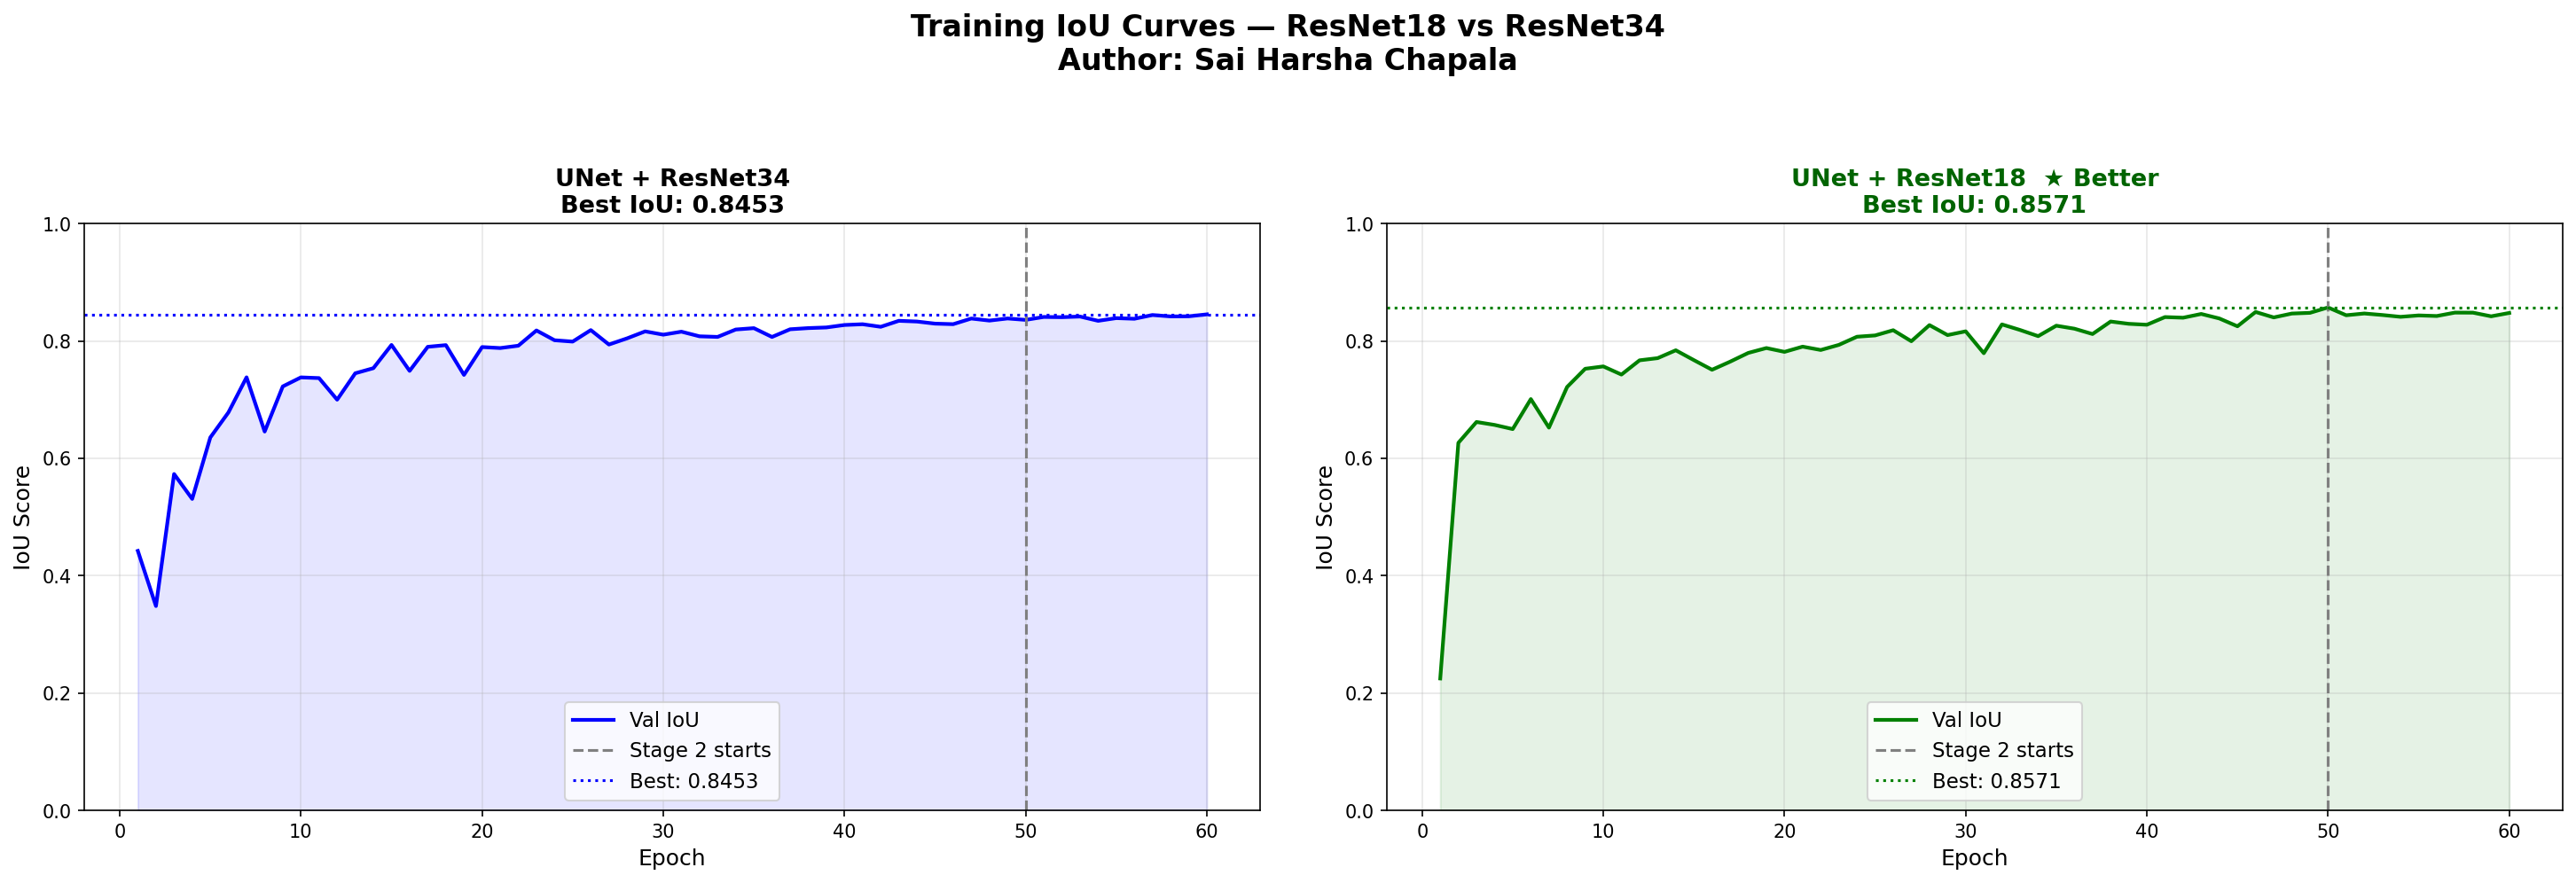

Saved iou_curves_comparison.png


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7), dpi=150)
fig.patch.set_facecolor('white')
fig.suptitle(
    'Training IoU Curves — ResNet18 vs ResNet34\n'
    'Author: Sai Harsha Chapala',
    fontsize=16, fontweight='bold'
)

ep34 = range(1, len(history['iou'])+1)
ep18 = range(1, len(history_r18['iou'])+1)

# ResNet34
axes[0].plot(ep34, history['iou'], 'b-', linewidth=2, label='Val IoU')
axes[0].axvline(x=50, color='gray', linestyle='--',
                linewidth=1.5, label='Stage 2 starts')
axes[0].axhline(y=best, color='blue', linestyle=':',
                linewidth=1.5, label=f'Best: {best:.4f}')
axes[0].fill_between(ep34, 0, history['iou'], alpha=0.1, color='blue')
axes[0].set_title(f'UNet + ResNet34\nBest IoU: {best:.4f}',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('IoU Score', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# ResNet18
axes[1].plot(ep18, history_r18['iou'], 'g-', linewidth=2, label='Val IoU')
axes[1].axvline(x=50, color='gray', linestyle='--',
                linewidth=1.5, label='Stage 2 starts')
axes[1].axhline(y=best_r18, color='green', linestyle=':',
                linewidth=1.5, label=f'Best: {best_r18:.4f}')
axes[1].fill_between(ep18, 0, history_r18['iou'], alpha=0.1, color='green')
axes[1].set_title(f'UNet + ResNet18  ★ Better\nBest IoU: {best_r18:.4f}',
                   fontsize=13, fontweight='bold', color='darkgreen')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('IoU Score', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout(pad=3.0)
plt.savefig(f'{OUT}/iou_curves_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('Saved iou_curves_comparison.png')

In [54]:
print('='*60)
print('  FINAL RESULTS — TGS Salt Segmentation')
print('  Author : Sai Harsha Chapala')
print('  Paper  : DOI 10.48047/IJFANS/V11/I12/215')
print('='*60)
print(f'  UNet + ResNet18  : {best_r18:.4f}  <- Best single model')
print(f'  UNet + ResNet34  : {best:.4f}')
print(f'  Paper Ensemble   : 0.8699')
print('='*60)
print()
print('GitHub README table:')
print('| Model                  | IoU    |')
print('|------------------------|--------|')
print(f'| UNet + ResNet18  | {best_r18:.4f} |')
print(f'| UNet + ResNet34  | {best:.4f} |')
print(f'| Paper Ensemble   | 0.8699 |')
print()


  FINAL RESULTS — TGS Salt Segmentation
  Author : Sai Harsha Chapala
  Paper  : DOI 10.48047/IJFANS/V11/I12/215
  UNet + ResNet18  : 0.8571  <- Best single model
  UNet + ResNet34  : 0.8453
  Paper Ensemble   : 0.8699

GitHub README table:
| Model                  | IoU    |
|------------------------|--------|
| UNet + ResNet18  | 0.8571 |
| UNet + ResNet34  | 0.8453 |
| Paper Ensemble   | 0.8699 |

